In [1]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os
from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.tile.bin_2d import Tile2Symb2dBin

from tests.experimental.grayscale.test_loop import Params, test_loop

SYMBOLS = get_asciis()
FONT_PATH = "../../../../fonts/Inconsolata-Regular.ttf"
FONT_SIZE = 14
MAX_WIDTH = 80
MAX_HEIGHT = 24
IMG_SET_PATH = "../../../../imgs/BSDS500"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:5]]


def make_converter(params: Params):
    return Tile2Symb2dBin(
        symbols=SYMBOLS,
        font=ImageFont.truetype(params.font_path, params.font_size),
        **params.converter_args)

Min: 0.0334 | Max: 0.0609 | Mean: 0.0436 | Std: 0.0097
Min: 0.0872 | Max: 0.1186 | Mean: 0.1066 | Std: 0.0109
Min: 0.1096 | Max: 0.1686 | Mean: 0.1422 | Std: 0.0230
Min: 0.1281 | Max: 0.1796 | Mean: 0.1554 | Std: 0.0178
Min: 0.0974 | Max: 0.1746 | Mean: 0.1305 | Std: 0.0280
Min: 0.1222 | Max: 0.1892 | Mean: 0.1479 | Std: 0.0247
Min: 0.1174 | Max: 0.1721 | Mean: 0.1467 | Std: 0.0207
Min: 0.1156 | Max: 0.1892 | Mean: 0.1517 | Std: 0.0278
Min: 0.1197 | Max: 0.1848 | Mean: 0.1491 | Std: 0.0228


C:\Users\wojte\AppData\Local\Temp\ipykernel_26844\2571842847.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


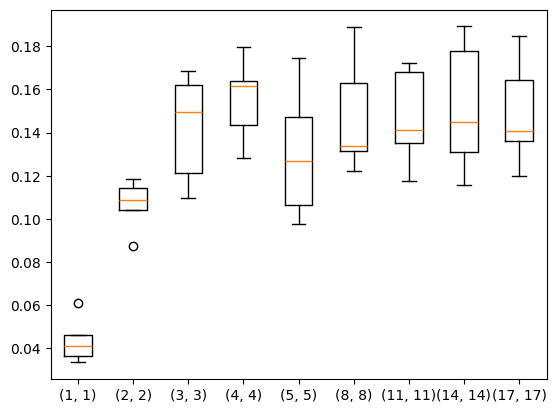

In [2]:
# bins

params_space = [
    (bins, bins) for bins in range(1, 5, 1)
]
params_space += [
    (bins, bins) for bins in range(5, 18, 3)
]

params_space = list(
    map(lambda bins: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={'bins': bins},
        preprocess_args={}),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.converter_args['bins'] for param in params_space])
plt.show()

Min: 0.0727 | Max: 0.1176 | Mean: 0.0954 | Std: 0.0168
Min: 0.0956 | Max: 0.1650 | Mean: 0.1293 | Std: 0.0248
Min: 0.1446 | Max: 0.2153 | Mean: 0.1687 | Std: 0.0268
Min: 0.1643 | Max: 0.2326 | Mean: 0.1961 | Std: 0.0223
Min: 0.1701 | Max: 0.2444 | Mean: 0.2140 | Std: 0.0270


C:\Users\wojte\AppData\Local\Temp\ipykernel_26844\549677722.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


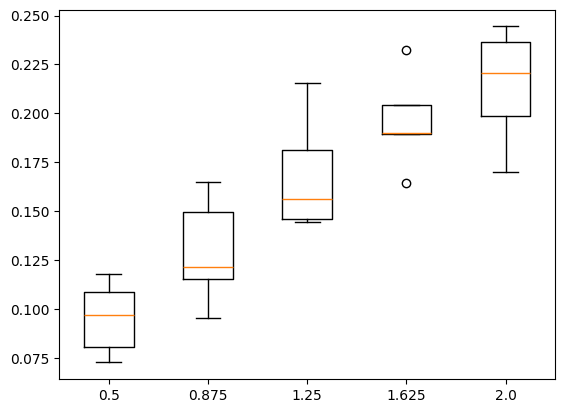

In [3]:
# contrast

params_space = [
    {'contrast': c} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()

In [3]:
import math
from PIL import Image
from image.processing import preprocess_img
from rendering.terminal import print_gallery


converter = Tile2Symb2dBin(symbols=SYMBOLS,
                           font=ImageFont.truetype(FONT_PATH, FONT_SIZE))

results = []
for img_path in IMG_PATHS:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    win_width = math.ceil(img.size[0] / MAX_WIDTH)
    win_height = math.ceil(img.size[1] / MAX_HEIGHT)
    results.append(converter.process_image(img, (win_width, win_height)))

print_gallery(results, 1)

---------------------------------------------------------------------------
 | ;;;_____;_______,,____;;|/\|\/\;;;;;;>r;;;~;=;1;;~----;;~~~~'~~--` -` | 
 | ^!!***i}J}{IIISSSSn4U423[2]UoA[n}>><)v]lASSX[2}{I{2xcscxc==v;=/;;,..  | 
 | `` ```` ----------^!!ixcclI2JV**>~~-----~~"+++{{))1!"^^'~~'-~r~~:- `  | 
 | `` ``````  ``` ```~>~:~^---   `  `` `  ``.::.``` `  ` `` ` `` `` `    | 
 | euueua;;___________;__;;__________,,,,,,,,__,.: `` ` ` `` `  `` `` `  | 
 | 4bdbdm&QQQQQQQQQQBBBBBBBBBBQQQQQQQQQQQQQQQQQQQ&Q&&&Q&&ppppqqGweueeua; | 
 | mdbdbd0QQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQbmdbmddmb( | 
 | bbdm&QQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQbmmddbd( | 
 | mbbdmbQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQmmmmbmi | 
 | dbddbQQQQQQQQQQQQBQQQQ@QQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQ&mddddb( | 
 | bmmbQQQQQQQQQQQBBBF?~~::~!+!+FH$QQQBQQQQQQQQQQQQQQQQQQQQQQQQQQ&dbmdb( | 
 | mdQQQQQQQQBBBBBBBS::::::::::::~~!HQQQQQQQQBQQQQQQQQQQQQQQQQQQQQbmmdb1 | 
 | mbdQQQQQQ